# 🏠 House Price Prediction

**Goal:** predict house prices from features like area, bedrooms, location, and age — using **regression**.

> 💡 Regression = predicting a *number* (here: price). We compare a simple linear model with a powerful Random Forest.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline
sns.set_theme(style="whitegrid")

## Step 1: Load the data

In [2]:
df = pd.read_csv("data/housing.csv")
print("Shape:", df.shape)
print()
print(df.head())
print()
df.info()

Shape: (5000, 6)

   Area_sqft  Bedrooms  Bathrooms  Location  Age_years   Price
0       3674         2          2  Downtown         17  676772
1       1360         2          1  Downtown         18  385807
2       1794         3          1  Downtown         12  438484
3       1630         2          2    Suburb          3  305458
4       1595         1          1    Suburb         30  334672

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Area_sqft  5000 non-null   int64
 1   Bedrooms   5000 non-null   int64
 2   Bathrooms  5000 non-null   int64
 3   Location   5000 non-null   str  
 4   Age_years  5000 non-null   int64
 5   Price      5000 non-null   int64
dtypes: int64(5), str(1)
memory usage: 234.5 KB


## Step 2: Quick stats

`describe()` shows averages, min/max, and spread of every numeric column.

In [3]:
print(df.describe().round(0))
print()
print("Locations:", df["Location"].value_counts().to_dict())

       Area_sqft  Bedrooms  Bathrooms  Age_years     Price
count     5000.0    5000.0     5000.0     5000.0    5000.0
mean      2273.0       3.0        2.0       15.0  475583.0
std       1006.0       1.0        1.0        9.0  159397.0
min        500.0       1.0        1.0        0.0   78563.0
25%       1414.0       2.0        1.0        7.0  346263.0
50%       2287.0       3.0        3.0       15.0  475131.0
75%       3145.0       4.0        4.0       22.0  608494.0
max       4000.0       5.0        4.0       30.0  904019.0

Locations: {'Suburb': 2443, 'Downtown': 1533, 'Rural': 1024}


## Step 3: EDA — Does area drive price?

A **scatter plot** shows the relationship between two numbers. Points colored by location reveal if location matters too.

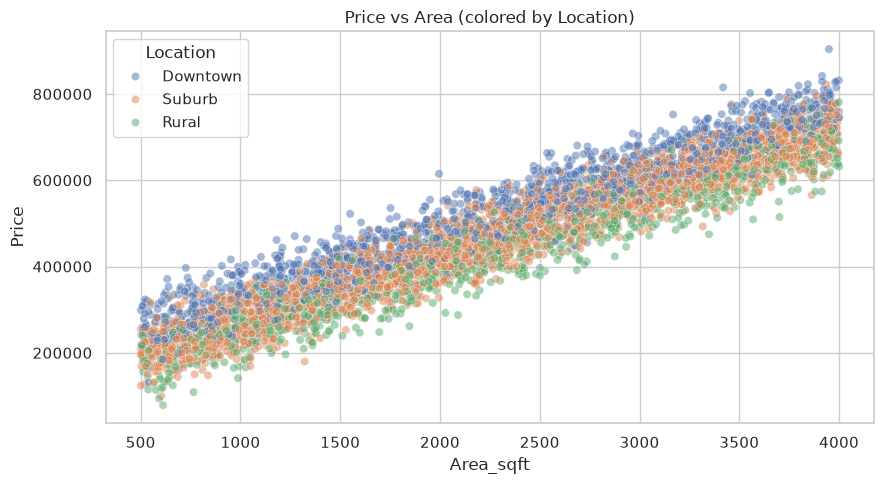

In [4]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x="Area_sqft", y="Price", hue="Location", alpha=0.5)
plt.title("Price vs Area (colored by Location)")
plt.tight_layout()
plt.show()

## Step 4: EDA — Price by location

A **boxplot** shows the median and spread of prices inside each location.

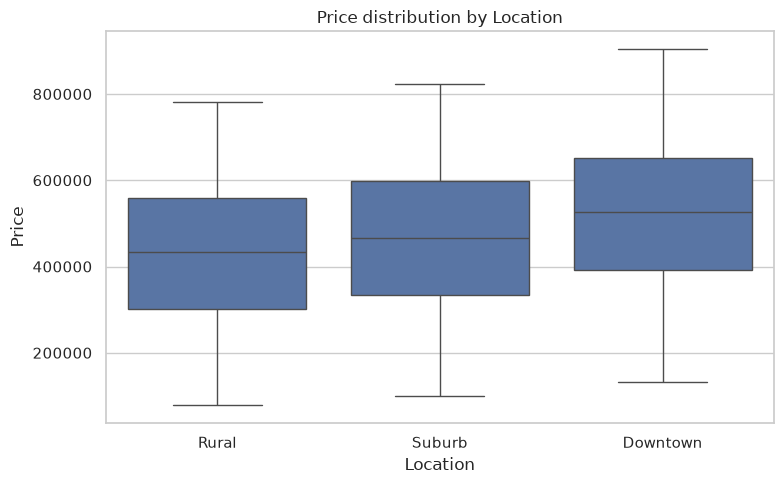

In [5]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Location", y="Price", order=["Rural", "Suburb", "Downtown"])
plt.title("Price distribution by Location")
plt.tight_layout()
plt.show()

## Step 5: One-hot encode Location

Models need numbers, not text. **One-hot encoding** turns `Location` into 3 yes/no columns: `Location_Downtown`, `Location_Suburb`, `Location_Rural`.

In [6]:
X = pd.get_dummies(df.drop(columns=["Price"]), columns=["Location"], dtype=int)
y = df["Price"]
print("Feature columns:", list(X.columns))
print()
print(X.head())

Feature columns: ['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age_years', 'Location_Downtown', 'Location_Rural', 'Location_Suburb']

   Area_sqft  Bedrooms  Bathrooms  Age_years  Location_Downtown  \
0       3674         2          2         17                  1   
1       1360         2          1         18                  1   
2       1794         3          1         12                  1   
3       1630         2          2          3                  0   
4       1595         1          1         30                  0   

   Location_Rural  Location_Suburb  
0               0                0  
1               0                0  
2               0                0  
3               0                1  
4               0                1  


## Step 6: Split into train and test sets

We train on 80% of the data and test on the **unseen** 20% — this tells us how the model performs on new houses.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

Train size: 4000 | Test size: 1000


## Step 7: Train two models

- **LinearRegression** — fits one straight-line formula through the data. Simple and fast.
- **RandomForestRegressor** — builds 100 decision trees and averages them. Captures curves and interactions.

In [8]:
lin = LinearRegression()
lin.fit(X_train, y_train)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("Both models trained!")

Both models trained!


## Step 8: Compare with MAE, RMSE, R²

- **MAE** (Mean Absolute Error): average mistake in dollars. Lower = better.
- **RMSE**: like MAE but punishes big mistakes more. Lower = better.
- **R²**: score from 0 to 1. It answers: *"how much of the price variation does the model explain?"* R² = 0.90 means the model explains 90% of why prices differ — only 10% is left as unexplained noise. Closer to 1 = better.

In [9]:
for name, model in [("LinearRegression", lin), ("RandomForest", rf)]:
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"{name:18s}  MAE=${mae:,.0f}   RMSE=${rmse:,.0f}   R2={r2:.4f}")

LinearRegression    MAE=$24,584   RMSE=$30,799   R2=0.9628
RandomForest        MAE=$27,579   RMSE=$34,460   R2=0.9534


## Step 9: Residual plot — where does the model go wrong?

**Residual** = actual price − predicted price. A good model has residuals scattered randomly around zero, with no pattern.

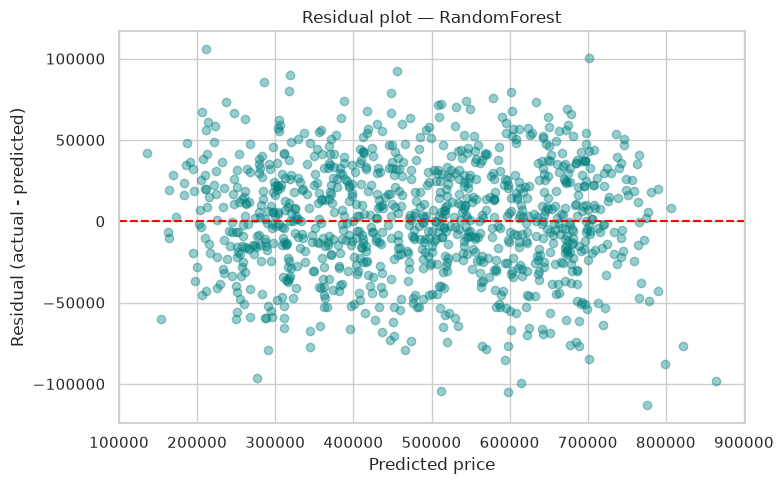

In [10]:
pred_rf = rf.predict(X_test)
residuals = y_test - pred_rf

plt.figure(figsize=(8, 5))
plt.scatter(pred_rf, residuals, alpha=0.4, color="teal")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted price")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residual plot — RandomForest")
plt.tight_layout()
plt.show()

## Step 10: Which features matter most?

RandomForest tells us **feature importance** — how much each column helped the predictions.

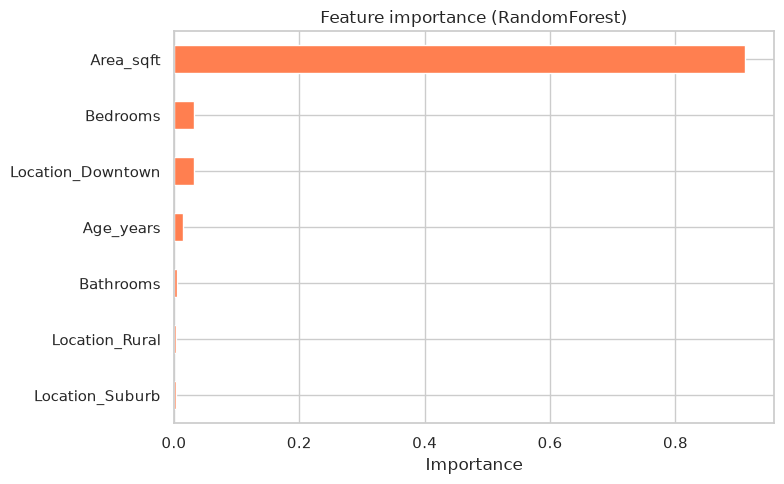

In [11]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="coral")
plt.title("Feature importance (RandomForest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## ✅ Conclusion

- **Area** is the biggest price driver, **location** adds a clear premium (Downtown > Suburb > Rural).
- **LinearRegression wins slightly here** — because this dataset was built from a linear formula, the straight-line model fits it best. On real messy data, RandomForest often wins.
- R² ≈ 0.97 means the model explains 97% of price variation — excellent fit.

> 🎓 Can you explain *every* cell above in your own words? If yes — this project is truly yours.